
*Technical University of Munich<br>
Professorship of Environmental Sensing and Modeling<br><br>*
**Author:**  Daniel Kühbacher<br>
**Date:**  24.03.2026

--- 

# VISUM Model Preprocessing

<!--Notebook description and usage information-->
This notebook processes the raw VISUM traffic model export and converts the data into *.gpkg files.

In [1]:
import sys
import geopandas as gpd

# import custom modules
sys.path.append('../../utils/')
import data_paths
from excel_calendar import Calendar
from traffic_counts import TrafficCounts

## Import VISUM traffic model data

The VISUM traffic model provides geoinformation for every road in the region of interest. This includes the indicated speed, the road gradient, road type, hour capacity and the daily average traffic of different vehicle classes.<br>
Additionally, origin-destination matricies, a fundamental input for macroscopic traffic models, are imported. These include the number of starts within the region and will be used to determine cold start emissions.

In [2]:
# import visum data
visum_link_path = data_paths.VISUM_2025_FOLDER_PATH + "Analyse 2025 Links_link.SHP"
visum_zone_path = data_paths.VISUM_2025_FOLDER_PATH + "aktuelles Modell 2025_zone.SHP"


visum_links = gpd.read_file(visum_link_path)
visum_zones = gpd.read_file(visum_zone_path)

print(f"Coordinate reference system of VISUM link data: {visum_links.crs}")
print(f"Coordinate reference system of VISUM zones data: {visum_zones.crs}")

Coordinate reference system of VISUM link data: EPSG:25832
Coordinate reference system of VISUM zones data: EPSG:25832


In [3]:
# column mapping for new model
visum_links.rename(columns ={'Kfz_Bela~1':'SUMME_KFZ', 
                             'VOLVEH_T~2': 'BEL_LKW_G', 
                             'VOLVEH_T~3': 'BEL_LKW_K', 
                             'VOLVEH_T~4': 'BEL_LKW_M',
                             'VOLVEH_T~5': 'BEL_PKW'}, inplace=True)

visum_zones.rename(columns ={'OTRAFFIC_P':'qv_pkw', 
                             'OTRAFFIC~7': 'qv_lkw_k', 
                             'OTRAFFIC~8': 'qv_lkw_g', 
                             'OTRAFFI~11': 'qv_lkw_m'}, inplace=True)


# fix datatypes
visum_links['V0PRT'] = visum_links['V0PRT'].str.split('km/h').str[0].astype(int)
visum_links['LENGTH'] = visum_links['LENGTH'].str.split('km').str[0].apply(lambda x: x.replace(',', '.')).astype(float)

## Notebook functions

In [4]:
def hbefa_road_type(visum_typeno, speed) -> str: 
    """returns hbefa compatible road type for all road types in the visum traffic model of Munich.
    The information below was collected from the official documentation of the VIUSM model and 
    matched to HBEFA types. Further processing might be necessary if not all road types are used.
    
    0-10: gesperrte und fiktive Strecken sowie Fuß- und Radwege
    100-199: Autobahnen
    200-299: Bundesstraßen
    300-399: Staatsstraßen
    400-499: Kreisstraßen
    500-599: Gemeindestraßen
    600-699: Hauptstraßen (innerorts)
    700-799: Erschließungsstraßen
    800-899: Mittlerer Ring
    900-999: ÖV Strecken

    Args:
        visum_typeno (string object): defines the road type in the VISUM model

    Returns:
        str: HBEFA compatible road type
    """
    
    int_typeno = int(visum_typeno)
    
    if 0 <= int_typeno <=10: 
        return 'none'
    if 100 <= int_typeno <=199:
        return 'Motorway-Nat'
    if 200 <= int_typeno <=499:
        if speed >=70: 
            return 'TrunkRoad/Primary-National'
        else:
            return 'Distributor/Secondary'
    if 500 <= int_typeno <=699: 
        return 'Distributor/Secondary'
    if 700 <= int_typeno <=799: 
        return 'Access-residential'
    if 800 <= int_typeno <=899: 
        return 'TrunkRoad/Primary-City'
    if 900 <= int_typeno <=999: 
        return 'none'
    else: 
        return 'none'

In [5]:
def hbefa_road_gradients(visum_gradient) -> str:
    """Converts any road gradient value to the closest gradient 
    value available in HBEFA and returns it as a string.

    Args:
        road_gradient(float): Slope of the road

    Returns:
        str: road gradient string (e.g., '+6%')
    """
    hbefa_gradients = [-6, -4, -2, 0, 2, 4, 6]
    
    hbefa_gradient = min(hbefa_gradients, key=lambda x: abs(x - visum_gradient))
    hbefa_gradient_string = str(hbefa_gradient)+'%'
    
    return hbefa_gradient_string

In [6]:
def hbefa_speed_value(hbefa_road_type:str,
                     speed:int) -> int:
    
        """Converts speed value to closest speed value available in HEBFA

        Args:
            road_type (str): road type 
            speed (int): speed value

        Returns:
            int: Speed value available in HBEFA
        """
        try:
            hbefa_speed = {'Motorway-Nat': [80, 90, 100, 110, 120, 130],
                           'Motorway-City': [60, 70, 80, 90, 100, 110],
                           'TrunkRoad/Primary-National': [70, 80, 90, 100, 110, 120],
                           'TrunkRoad/Primary-City': [50, 60, 70, 80, 90],
                           'Distributor/Secondary': [30, 40, 50, 60, 70, 80],
                           'Local/Collector': [30, 40, 50, 60],
                           'Access-residential': [30, 40, 50]}
            
            hbefa_speed = min(hbefa_speed[hbefa_road_type], key=lambda x: abs(x - speed))
            
        except KeyError as e: 
            print('error ' + str(e))
            print(f'Road type: {hbefa_road_type}, Speed: {speed}')
        return hbefa_speed

## Data processing
- Drop columns with DTV < 1
- Convert road type, speed and gradient to HBEFA compatible values
- Drop columns with undefined road type
- Rename columns

In [7]:
# drop columns where the daily traffic ('SUMME_KFZ') is < 1 vehicle
visum_links = visum_links.drop(visum_links.loc[(visum_links['SUMME_KFZ'] < 1)].index, axis = 0)

# add road type to visum link data and drop entries with 'None' road type
visum_links['road_type'] = visum_links.apply(lambda row: hbefa_road_type(row['TYPENO'],
                                                                         row['V0PRT']), axis = 1)
visum_links = visum_links.drop(visum_links.loc[(visum_links['road_type'] == 'none')].index, axis = 0)

# convert road gradient values
visum_links['hbefa_gradient'] = visum_links.apply(lambda row: hbefa_road_gradients(row['SLOPE']), axis = 1)

# convert hbefa speed values
visum_links['hbefa_speed'] = visum_links.apply(lambda row: hbefa_speed_value(speed = row['V0PRT'],
                                                                             hbefa_road_type = row['road_type']), axis =1)

# aggregate heavy vehicle rows
visum_links['dtv_HGV'] = visum_links[['BEL_LKW_M','BEL_LKW_G']].sum(axis = 1)

# rename rows
visum_links = visum_links.rename(columns={'SUMME_KFZ' : 'dtv_SUM',
                                          'NO' : 'road_link_id',
                                          'BEL_PKW' : 'dtv_PC',
                                          'BEL_LKW_K' : 'dtv_LCV',
                                          'CAPPRT' : 'hour_capacity',
                                          'V0PRT' : 'speed',
                                          'NUMLANES' : 'lanes'})

# reset index
visum_links = visum_links.reset_index(drop = True)

# Scaling road types
Since there are no scaling factors for every road type but aggregated time profiles, a column 'scaling_road_type' is introduced to match the scaling factors with the visum model

In [8]:
# since there are no scaling factors for every road type but aggregated time profiles, 
# a column 'scaling_road_type' is introduced to match the scaling factors with the visum model
scaling_road_types = {'Motorway-Nat' : 'Motorway-Nat',
                      'Motorway-City' : 'Motorway-Nat',
                      'TrunkRoad/Primary-National' : 'Distributor/Secondary',
                      'TrunkRoad/Primary-City' : 'TrunkRoad/Primary-City',
                      'Distributor/Secondary' : 'Distributor/Secondary',
                      'Local/Collector' : 'Distributor/Secondary',
                      'Access-residential' : 'Distributor/Secondary'}

visum_links['scaling_road_type'] = visum_links['road_type'].map(scaling_road_types)

<Axes: >

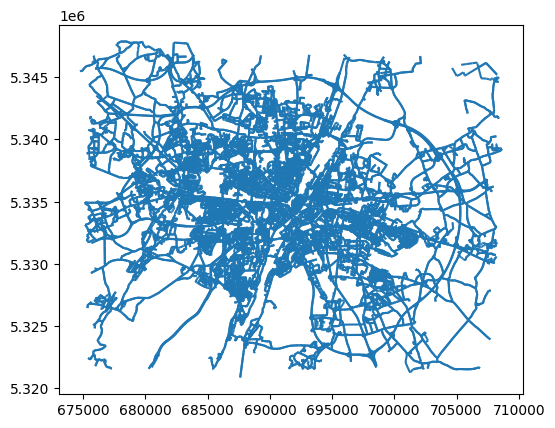

In [9]:
visum_links.plot()

# Vehicle share correction factors
Scaling the VISUM model by traffic counting data requires vehicle-specific counting data as provided with classified 8+1 counts. With these counts it is possible to estimate an average vehicle share for each road type, however, it is not possible to account for spatial differences. While the total traffic volume is driven by personal cars, this effect is not severe for this vehicle type. In contrast, heavy trucks and light cargo vehicle show significant inter road-type differences in vehicle share which should be accounted with a correction factor. The correction factor is based on actual shares provided by the VISUM model and counted shares from traffic counting stations. 

In [10]:
# calculate vehicle shares of the vehicle classes
visum_links['delta_HGV'] = visum_links['dtv_HGV'] / visum_links['dtv_SUM']
visum_links['delta_LCV'] = visum_links['dtv_LCV'] / visum_links['dtv_SUM']
visum_links['delta_PC'] = visum_links['dtv_PC'] / visum_links['dtv_SUM']

In [11]:
cal = Calendar()
cycles = TrafficCounts()

ref_year = 2025

dates = cal.get_calendar()
dates['combined_day_type'] = dates['date'].apply(cal.get_day_type_combined)
normweekdays_ref = dates [(dates['date'].between(f"{ref_year}-01-01",f"{ref_year}-12-31")) &
                           (dates['combined_day_type'] == 0)]['date']

# calculate vehicle shares on average norm weekday
# these values are used to calculate the vehicle share correction factors
shares_ref = cycles.vehicle_shares.loc[:,:,normweekdays_ref].reset_index()
shares_ref = shares_ref.groupby(['scaling_road_type','vehicle_class'])[0].mean()

visum_links['hgv_corr'] = visum_links.apply(\
    lambda row : row['delta_HGV'] / shares_ref.loc[row['scaling_road_type'],'HGV'], axis = 1)

visum_links['lcv_corr'] = visum_links.apply(\
    lambda row : row['delta_LCV'] / shares_ref.loc[row['scaling_road_type'],'LCV'], axis = 1)

In [12]:
cycles.vehicle_shares

vehicle_class  scaling_road_type       date      
BUS            Distributor/Secondary   2025-01-01    0.012303
HGV            Distributor/Secondary   2025-01-01    0.004829
LCV            Distributor/Secondary   2025-01-01    0.043808
MOT            Distributor/Secondary   2025-01-01    0.005174
PC             Distributor/Secondary   2025-01-01    0.933885
                                                       ...   
BUS            TrunkRoad/Primary-City  2025-12-31    0.001488
HGV            TrunkRoad/Primary-City  2025-12-31    0.028068
LCV            TrunkRoad/Primary-City  2025-12-31    0.063172
MOT            TrunkRoad/Primary-City  2025-12-31    0.000641
PC             TrunkRoad/Primary-City  2025-12-31    0.906631
Length: 5475, dtype: float64

## Distribute cold starts
Distribute the zonal vehicle start information to all road links within a defined buffer distance. We exclusively distribute vehicle starts to road types of lower level. Vehicles on the motorway and primary city roads are assumed to run with hot exhaust. The redistribution is weighted by the share of the total traffic volume the road link represents within the buffer. The figure below shows the method in a visual way.

<img src="../../docs/img/vehicle_starts_distribution.png" width="600">

In [13]:
# add empty columns to the visum links file for cold starts
visum_zones = visum_zones.rename(columns={'qv_pkw': 'PC_starts',
                                          'qv_lkw_k': 'LCV_starts'})

visum_links[['PC_cold_starts', 'LCV_cold_starts']] = 0.0

# evenly distribute the number of starts to all road links within a buffered 
# region around the origin of starts
buffer_distance = 1500
road_type_to_include = ['Access-residential', 'Local/Collector', 'Distributor/Secondary']

for idx, row in visum_zones.iterrows():
    geometry = row.geometry.buffer(buffer_distance)
    geometry = gpd.GeoDataFrame(geometry=[row.geometry.buffer(buffer_distance)], crs=25832)
    combined = gpd.sjoin(geometry, visum_links, how="right", predicate='intersects').dropna()
    combined = combined[combined['road_type'].isin(road_type_to_include)]
    
    sum_dtv = combined['dtv_SUM'].sum()
    pc_cs = visum_links.loc[combined.index, 'dtv_SUM'] * row['PC_starts']/sum_dtv
    visum_links.loc[combined.index, 'PC_cold_starts'] += pc_cs
    
    lcv_cs = visum_links.loc[combined.index, 'dtv_SUM'] * row['LCV_starts']/sum_dtv
    visum_links.loc[combined.index, 'LCV_cold_starts'] += lcv_cs

## Save processed data

In [14]:
links_columns_to_keep = ['road_link_id', 'road_type', 'scaling_road_type','hour_capacity',
                         'lanes', 'hbefa_speed', 'speed', 'hbefa_gradient', 'dtv_SUM',
                         'delta_PC', 'delta_LCV', 'delta_HGV', 'hgv_corr', 'lcv_corr', 
                         'PC_cold_starts', 'LCV_cold_starts', 'geometry']


visum_links[links_columns_to_keep].to_file(data_paths.VISUM_2025_FOLDER_PATH+'visum_links_2025.gpkg',
                                           driver='GPKG')